# Packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import gempy as gp
import gempy_viewer as gpv
import HelperMethods
import threading
import os

BASE_DIR = os.getcwd()
data_dir = os.path.abspath(os.path.join(BASE_DIR, '..', '..', 'Data', 'Input_Data'))
geomodel_dir = os.path.abspath(os.path.join(BASE_DIR, '..', '..', 'Data', 'Output_Data'))

trigger_create_cross_section = True

Setting Backend To: AvailableBackends.numpy


# Model Parameters

In [2]:
# Model Extent
min_x = -707522
max_x = -677518
min_y =  4528453
max_y =  4549947
max_z =  505
model_depth = -500

# Set the extent of the model
extent=[min_x, max_x, max_y, min_y, model_depth, max_z]

# Set model resolution
nx = ny = nz = 64  # Define grid resolution
resolution = [nx, ny, nz]

# Topography
path_to_topography_reduced = os.path.join(data_dir, 'Topographic_Data', 'topo_reduced_sf0.1.tif')

# Plutonic
gdf3_path = os.path.join(
    data_dir,
    'Plutonic_Data',
    'QGIS',
    'Plutonite_circum_points_incl_dip.gpkg'
)

# Stratigraphic
gdf4_path = os.path.join(
    data_dir,
    'Stratigraphic_Data',
    'QGIS'
)

# Setting Dip Angle

In [3]:
# Plutonite dip angle
plutonite_dip_angle = 70 # degrees

# Loading in Data Plutonite Model

In [4]:
# Import plutonite data
gdf3 = gpd.read_file(gdf3_path)

# Create a DataFrame with X and Y coordinates
orientations_df = pd.DataFrame({
    'X':            gdf3.geometry.x,
    'Y':            gdf3.geometry.y,
    'Z':            gdf3['elevation1'],
    'azimuth':      gdf3['angle'] + 90,
    'dip':          plutonite_dip_angle,
    'polarity':     1,
    'formation':    gdf3['GEOLOGY'],
    'formation_id': gdf3['fid']
})

# Skip first 4 rows as they are errouneous and sample every 10th point to reduce model overfitting
orientations_df = orientations_df.iloc[5:].reset_index(drop=True)[::10]

# Save the sampled orientations DataFrame to a CSV file
sampled_orientations_path = os.path.join(data_dir, 'Plutonic_Data', 'plutonic_orientations_points.csv')
orientations_df.to_csv(sampled_orientations_path, index=False)

In [5]:
points_df = pd.DataFrame({
    'X':            gdf3.geometry.x,
    'Y':            gdf3.geometry.y,
    'Z':            gdf3['elevation1'],
    'formation':    gdf3['GEOLOGY'],
    'formation_id': gdf3['fid']
})

# Skip first 4 rows
points_df = points_df.iloc[5:].reset_index(drop=True)

# Save the sampled points DataFrame to a CSV file
sampled_points_path = os.path.join(data_dir, 'Plutonic_Data', 'plutonic_contact_points.csv')
points_df.to_csv(sampled_points_path, index=False)

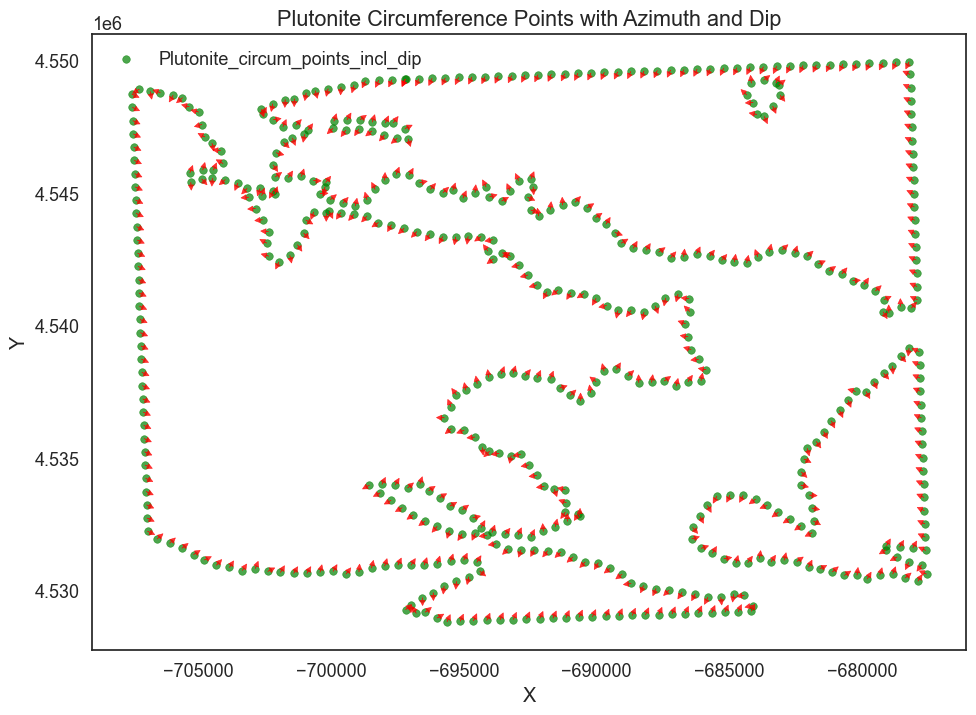

In [6]:
# Plot the points from gdf3
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the points
gdf3.plot(ax=ax, color='green', markersize=30, alpha=0.7, label='Plutonite_circum_points_incl_dip')


# Add arrows for azimuth where data is available
for idx, row in gdf3.iterrows():
    if pd.notna(row['az_to_centroid']) and pd.notna(row['dip']):
        # Arrow parameters
        arrow_length = 100  # arrow length in map units
        azimuth_rad = np.deg2rad(row['angle'])+90  # Convert azimuth to radians
        dx = arrow_length * np.sin(azimuth_rad)
        dy = arrow_length * np.cos(azimuth_rad)
        
        # Draw arrow
        ax.arrow(row.geometry.x, row.geometry.y, dx, dy, 
                head_width=200, head_length=200, fc='red', ec='red', alpha=0.8)
        

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Plutonite Circumference Points with Azimuth and Dip')
ax.legend()
plt.show()

# Loading in Data Stratigraphic Model

In [7]:
# Import stratigraphic data
points_incl_topo1 = gpd.read_file(os.path.join(gdf4_path, 'points_incl_topo.gpkg'))
points_incl_topo2 = gpd.read_file(os.path.join(gdf4_path, 'points22_incl_topo.gpkg'))
points_incl_topo3 = gpd.read_file(os.path.join(gdf4_path, 'points3_incl_topo.gpkg'))
points_incl_topo4 = gpd.read_file(os.path.join(gdf4_path, 'points4_incl_topo.gpkg'))

points_incl_topo1_df    = pd.DataFrame({
    'X': points_incl_topo1.geometry.x,
    'Y': points_incl_topo1.geometry.y,
    'Z': points_incl_topo1['elevation1'],
    'formation': points_incl_topo1['geology'],
    'formation_id': points_incl_topo1['id']
})

points_incl_topo1_df    = points_incl_topo1_df.loc[2:]

points_incl_topo2_df    = pd.DataFrame({
    'X': points_incl_topo2.geometry.x,
    'Y': points_incl_topo2.geometry.y,
    'Z': points_incl_topo2['elevation1'],
    'formation': points_incl_topo2['geology'],
    'formation_id': points_incl_topo2['id']
})

points_incl_topo3_df    = pd.DataFrame({
    'X': points_incl_topo3.geometry.x,
    'Y': points_incl_topo3.geometry.y,
    'Z': points_incl_topo3['elevation1'],
    'formation': points_incl_topo3['geology'],
    'formation_id': points_incl_topo3['id']
})

points_incl_topo4_df    = pd.DataFrame({
    'X': points_incl_topo4.geometry.x,
    'Y': points_incl_topo4.geometry.y,
    'Z': points_incl_topo4['elevation1'],
    'formation': points_incl_topo4['geology'],
    'formation_id': points_incl_topo4['id']
})


points_incl_topo_all_df = pd.concat([points_incl_topo1_df, points_incl_topo2_df, points_incl_topo3_df, points_incl_topo4_df], ignore_index=True)

# Assign correct formation IDs based on formation names
points_incl_topo_all_df.loc[points_incl_topo_all_df['formation'] == 'Upper Carboniferous Volcanics', 'formation_id'] = 1
points_incl_topo_all_df.loc[points_incl_topo_all_df['formation'] == 'Mid Carboniferous Shales', 'formation_id']      = 2
points_incl_topo_all_df.loc[points_incl_topo_all_df['formation'] == 'Visean Shales', 'formation_id']                 = 3
points_incl_topo_all_df.loc[points_incl_topo_all_df['formation'] == 'Upper Devonian Siliciclastics', 'formation_id'] = 4

# Save the stratigraphic points DataFrame to a CSV file
points_incl_topo_all_df_path = os.path.join(data_dir, 'Stratigraphic_Data', 'stratigraphic_contact_points.csv')
points_incl_topo_all_df.to_csv(points_incl_topo_all_df_path, index=False)

# Formation Legend
# 1 = Upper Carboniferous Volcanics
# 2 = Mid Carboniferous Shales
# 3 = Visean Shales
# 4 = Upper Devonian Siliciclastics

In [8]:
# Import stratigraphic data with orientations
points_orientations_incl_topo1 = gpd.read_file(os.path.join(gdf4_path, 'points_orientations_incl_topo.gpkg'))
points_orientations_incl_topo2 = gpd.read_file(os.path.join(gdf4_path, 'points2_orientations_incl_topo.gpkg'))
points_orientations_incl_topo3 = gpd.read_file(os.path.join(gdf4_path, 'points3_orientations_incl_topo.gpkg'))
points_orientations_incl_topo4 = gpd.read_file(os.path.join(gdf4_path, 'points4_orientations_incl_topo.gpkg'))


points_orientations_incl_topo1_df    = pd.DataFrame({
    'X': points_orientations_incl_topo1.geometry.x,
    'Y': points_orientations_incl_topo1.geometry.y,
    'Z': points_orientations_incl_topo1['elevation1'],
    'azimuth': points_orientations_incl_topo1['azimuth'],
    'dip': points_orientations_incl_topo1['dip'],
    'polarity': 1,
    'formation': points_orientations_incl_topo1['geology'],
    'formation_id': points_orientations_incl_topo1['id']
})

points_orientations_incl_topo2_df    = pd.DataFrame({
    'X': points_orientations_incl_topo2.geometry.x,
    'Y': points_orientations_incl_topo2.geometry.y,
    'Z': points_orientations_incl_topo2['elevation1'],
    'azimuth': points_orientations_incl_topo2['azimuth'],
    'dip': points_orientations_incl_topo2['dip'],
    'polarity': 1,
    'formation': points_orientations_incl_topo2['geology'],
    'formation_id': points_orientations_incl_topo2['id']
})

points_orientations_incl_topo3_df    = pd.DataFrame({
    'X': points_orientations_incl_topo3.geometry.x,
    'Y': points_orientations_incl_topo3.geometry.y,
    'Z': points_orientations_incl_topo3['elevation1'],
    'azimuth': points_orientations_incl_topo3['azimuth'],
    'dip': points_orientations_incl_topo3['dip'],
    'polarity': 1,
    'formation': points_orientations_incl_topo3['geology'],
    'formation_id': points_orientations_incl_topo3['id']
})

points_orientations_incl_topo4_df    = pd.DataFrame({
    'X': points_orientations_incl_topo4.geometry.x,
    'Y': points_orientations_incl_topo4.geometry.y,
    'Z': points_orientations_incl_topo4['elevation1'],
    'azimuth': points_orientations_incl_topo4['azimuth'],
    'dip': points_orientations_incl_topo4['dip'],
    'polarity': 1,
    'formation': points_orientations_incl_topo4['geology'],
    'formation_id': points_orientations_incl_topo4['id']
})


# Combine all orientation DataFrames and remove first 18 of the first dataframe as they are redundant
points_orientations_incl_topo_all_df = pd.concat([points_orientations_incl_topo1_df.loc[:18], points_orientations_incl_topo2_df, points_orientations_incl_topo3_df, points_orientations_incl_topo4_df], ignore_index=True)

# Assign correct formation IDs based on formation names
points_orientations_incl_topo_all_df.loc[points_orientations_incl_topo_all_df['formation'] == 'Upper Carboniferous Volcanics', 'formation_id'] = 1
points_orientations_incl_topo_all_df.loc[points_orientations_incl_topo_all_df['formation'] == 'Mid Carboniferous Shales', 'formation_id']      = 2
points_orientations_incl_topo_all_df.loc[points_orientations_incl_topo_all_df['formation'] == 'Visean Shales', 'formation_id']                 = 3
points_orientations_incl_topo_all_df.loc[points_orientations_incl_topo_all_df['formation'] == 'Upper Devonian Siliciclastics', 'formation_id'] = 4


# Save the stratigraphic orientations DataFrame to a CSV file
points_orientations_incl_topo_all_df_path = os.path.join(data_dir, 'Stratigraphic_Data', 'stratigraphic_orientation_points.csv')
points_orientations_incl_topo_all_df.to_csv(points_orientations_incl_topo_all_df_path, index=False)

# Formation Legend
# 1 = Upper Carboniferous Volcanics
# 2 = Mid Carboniferous Shales
# 3 = Visean Shales
# 4 = Upper Devonian Siliciclastics

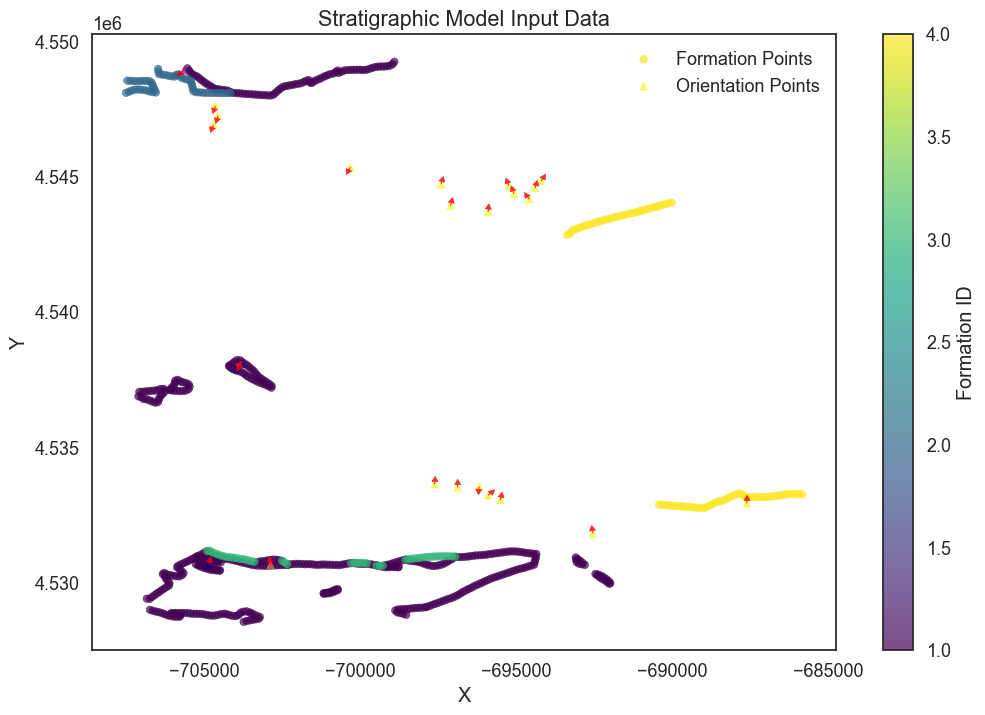

In [9]:
# Plot the points from gdf3
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the points
scatter1 = ax.scatter(points_incl_topo_all_df['X'], points_incl_topo_all_df['Y'], 
           c=points_incl_topo_all_df['formation_id'], cmap='viridis', s=30, alpha=0.7, label='Formation Points')
scatter2 = ax.scatter(points_orientations_incl_topo_all_df['X'], points_orientations_incl_topo_all_df['Y'],
           c=points_orientations_incl_topo_all_df['formation_id'], cmap='plasma', s=30, alpha=0.7, label='Orientation Points', marker='^')


# Add arrows for azimuth
for idx, row in points_orientations_incl_topo_all_df.iterrows():
    if pd.notna(row['azimuth']) and pd.notna(row['dip']):
        # Arrow parameters
        arrow_length = 100  # arrow length in map units
        azimuth_rad = np.deg2rad(row['azimuth'])  # Convert azimuth to radians
        dx = arrow_length * np.sin(azimuth_rad)
        dy = arrow_length * np.cos(azimuth_rad)
        
        # Draw arrow
        ax.arrow(row['X'], row['Y'], dx, dy,
                head_width=200, head_length=200, fc='red', ec='red', alpha=0.8)
        

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Stratigraphic Model Input Data')
ax.legend()
plt.colorbar(scatter1, ax=ax, orientation='vertical', label='Formation ID')
plt.show()

# Formation Legend
# 1 = Upper Carboniferous Volcanics
# 2 = Mid Carboniferous Shales
# 3 = Visean Shales
# 4 = Upper Devonian Siliciclastics

# Creating Plutonite Model

In [10]:
# Create geological model
plutonite_geo_model = gp.create_geomodel(
    project_name='AOI',
    extent=extent,
    # refinement=6,
    resolution=resolution,
    importer_helper=gp.data.ImporterHelper(
        path_to_orientations=os.path.join(data_dir, 'Plutonic_Data', 'plutonic_orientations_points.csv'),
        path_to_surface_points=os.path.join(data_dir, 'Plutonic_Data', 'plutonic_contact_points.csv'),
    )
)

# Set layers
gp.map_stack_to_surfaces(
    gempy_model=plutonite_geo_model,
    mapping_object={
        "Tournaisian_Plutonites": ["Tournaisian Plutonites"],
    }
)

# Set topography
gp.set_topography_from_file(grid=plutonite_geo_model.grid, filepath=path_to_topography_reduced)

# Compute plutonite model
plutonite_model = gp.compute_model(plutonite_geo_model)

Active grids: GridTypes.DENSE|TOPOGRAPHY|NONE
Setting Backend To: AvailableBackends.numpy
Chunking done: 372 chunks


C:\Users\maxha\PycharmProjects\Mineye-Terranigma\.venv\Lib\site-packages\gempy_engine\modules\activator\_soft_segment.py:95: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + bt.t.exp(x))


Chunking done: 7 chunks
Chunking done: 33 chunks
Chunking done: 12 chunks


Creating cross section...


C:\Users\maxha\PycharmProjects\Mineye-Terranigma\.venv\Lib\site-packages\gempy_viewer\API\_plot_2d_API.py:176: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()


Cross section created!


StructuralFrame(
	structural_groups=[
StructuralGroup(
	name=Tournaisian_Plutonites,
	structural_relation=StackRelationType.ERODE,
	elements=[
Element(
	name=Tournaisian Plutonites,
	color=#015482,
	is_active=True
)
]
)
],
	fault_relations=
[[False]],

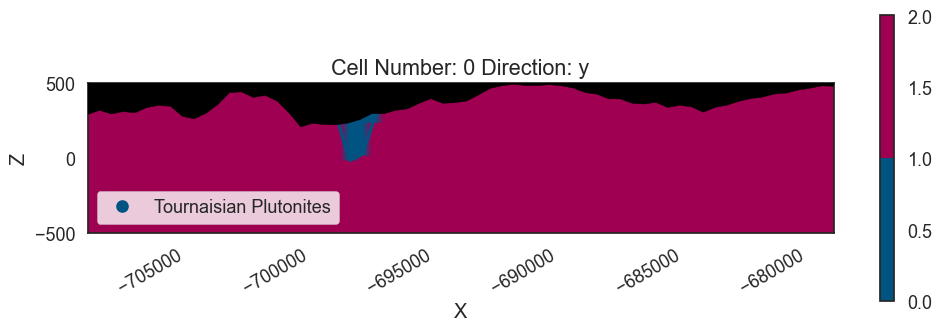

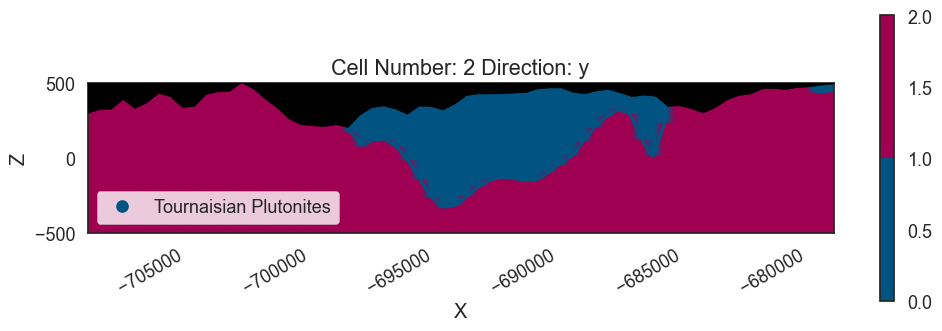

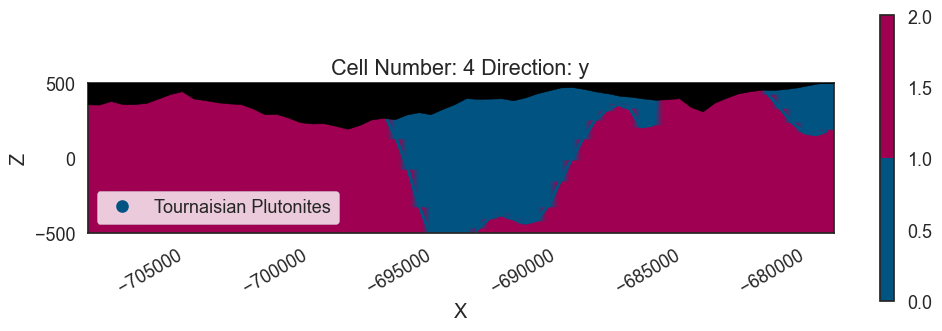

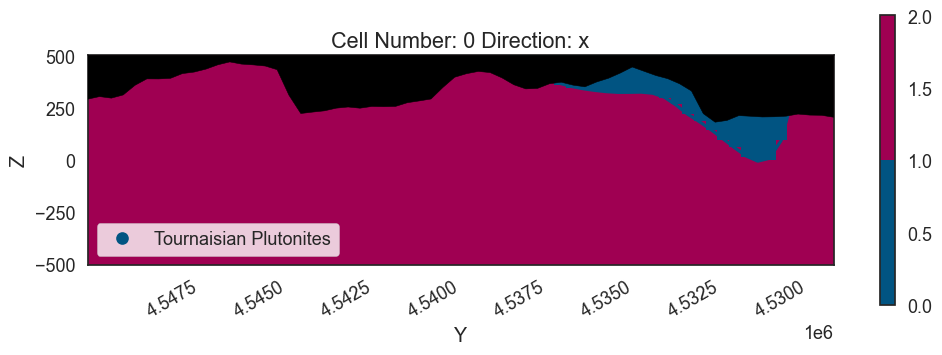

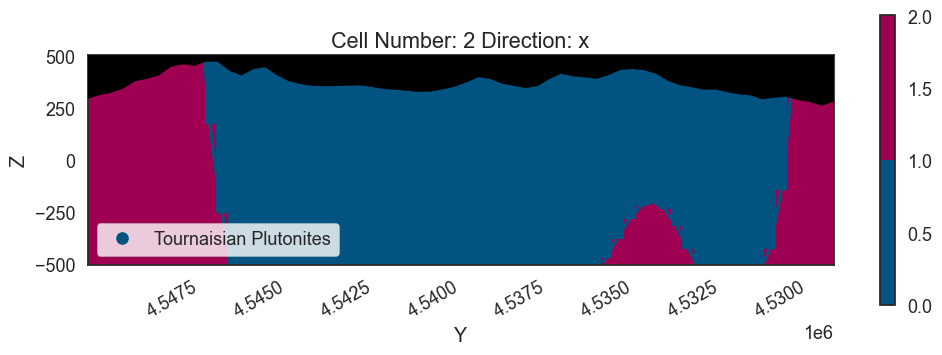

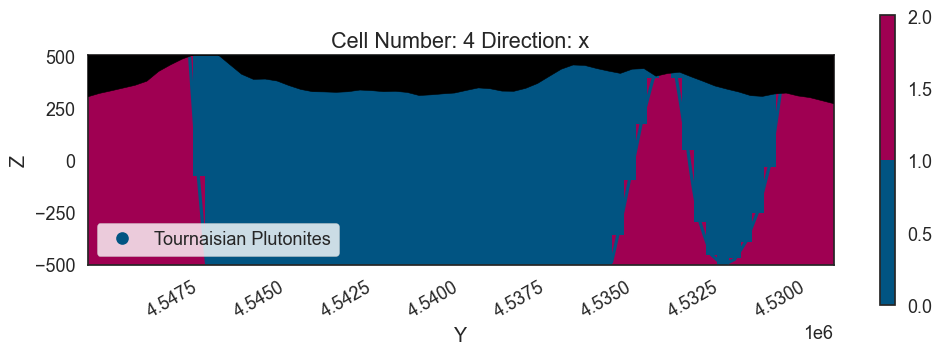

In [11]:
# Visualise plutonite model
threading.Thread(target=HelperMethods.plot_3d_async, args=(plutonite_geo_model,)).start()

if trigger_create_cross_section:
    print("Creating cross section...")
    HelperMethods.create_cross_section(plutonite_geo_model, cross_section=5)
    print("Cross section created!")
else:
    print("Cross section creation is disabled")

plutonite_geo_model.structural_frame

# Visualising Plutonic Shapes

In [12]:
# 1. Get the formation IDs for the model
plutonite_lith_block = plutonite_geo_model.solutions.raw_arrays.lith_block
plutonite_lith_block_reshaped = plutonite_lith_block.reshape(64,64,64)

# 2. Identify the formation ID of the Plutonite
plutonite_id = 1

# 3. Create a boolean mask for plutonite voxels
plutonite_mask = plutonite_lith_block_reshaped == plutonite_id

# 4. Get the coordinates of these voxels
voxel_coords = plutonite_geo_model.grid.regular_grid.values
voxel_coords_reshaped = voxel_coords.reshape(64, 64, 64, 3)

# 5. Select only the coordinates where lith_block == 1
plutonite_coords = voxel_coords_reshaped[plutonite_mask]

# 6. Flip Y coordinates
y_min, y_max = np.min(plutonite_coords[:, 1]), np.max(plutonite_coords[:, 1])
plutonite_coords_flipped = plutonite_coords.copy()
plutonite_coords_flipped[:, 1] = y_max - (plutonite_coords[:, 1] - y_min)


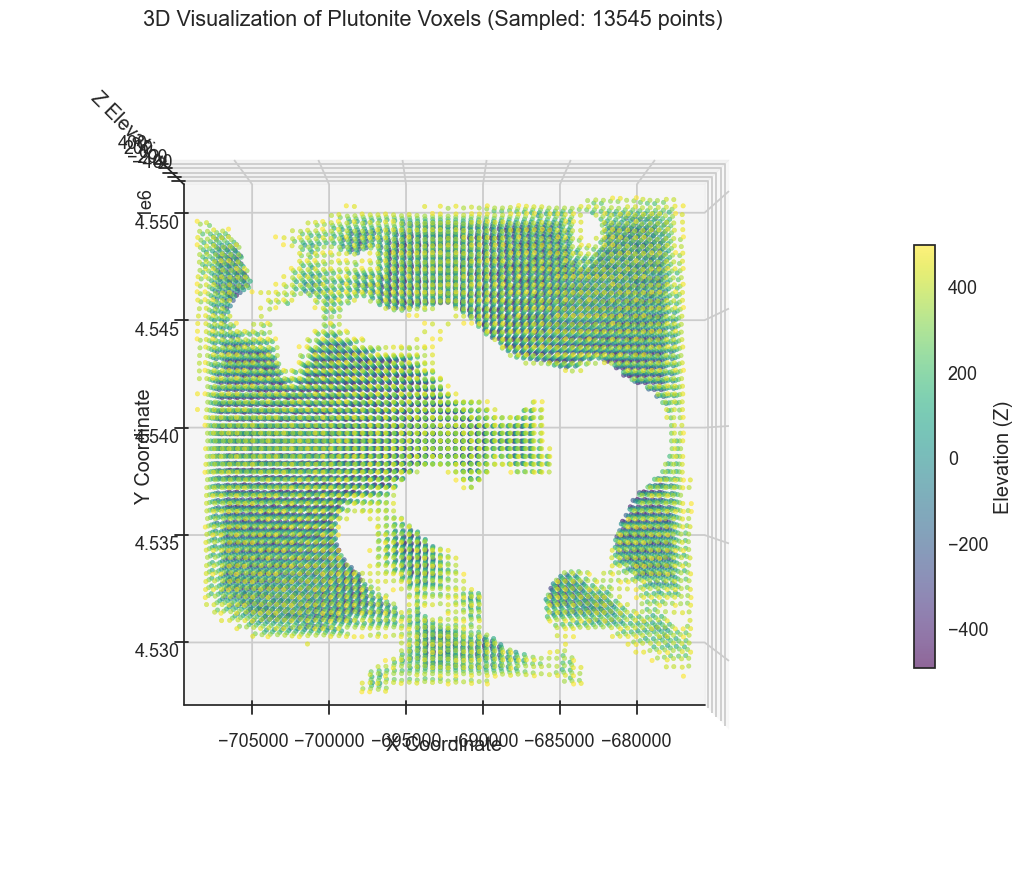

Original plutonite coordinates: 135445 points
Sampled plutonite coordinates: 13545 points


In [13]:
# Sample the plutonite coordinates for better performance
sample_step = 10
plutonite_coords_sampled = plutonite_coords_flipped[::sample_step]

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(plutonite_coords_sampled[:,0], 
                    plutonite_coords_sampled[:,1], 
                    plutonite_coords_sampled[:,2],
                    c=plutonite_coords_sampled[:,2], 
                    cmap='viridis', 
                    s=10, 
                    alpha=0.6)

plt.colorbar(scatter, ax=ax, label='Elevation (Z)', shrink=0.5)

ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Z Elevation')
ax.set_title(f'3D Visualization of Plutonite Voxels (Sampled: {len(plutonite_coords_sampled)} points)')

# Improve the view
ax.view_init(elev=90, azim=270)

plt.tight_layout()
plt.show()

print(f"Original plutonite coordinates: {len(plutonite_coords)} points")
print(f"Sampled plutonite coordinates: {len(plutonite_coords_sampled)} points")

# Combining Plutonic-Stratigraphic Data

In [14]:
# Combine orientation data
orientations_combined = pd.concat([
    pd.read_csv(os.path.join(data_dir, 'Plutonic_Data', 'plutonic_orientations_points.csv')),
    pd.read_csv(os.path.join(data_dir, 'Stratigraphic_Data', 'stratigraphic_orientation_points.csv'))
], ignore_index=True)

# Combine formation points data  
points_combined = pd.concat([
    pd.read_csv(os.path.join(data_dir, 'Plutonic_Data', 'plutonic_contact_points.csv')),
    pd.read_csv(os.path.join(data_dir, 'Stratigraphic_Data', 'stratigraphic_contact_points.csv'))
], ignore_index=True)

# Save combined datasets
orientations_combined.to_csv(os.path.join(data_dir, 'Stratigraphic_Data', 'plutonic_stratigraphic_orientations.csv'), index=False)
points_combined.to_csv(os.path.join(data_dir, 'Stratigraphic_Data', 'plutonic_stratigraphic_contact_points.csv'), index=False)

print(f"Combined orientations shape: {orientations_combined.shape}")
print(f"Combined points shape: {points_combined.shape}")


Combined orientations shape: (75, 8)
Combined points shape: (1198, 5)


# Creating Plutonic-Stratigraphic Model

In [15]:
# Create geological model
stratigraphic_geo_model = gp.create_geomodel(
    project_name='AOI',
    extent=extent,
    # refinement=6,
    resolution=resolution,
    importer_helper=gp.data.ImporterHelper(
        path_to_orientations=os.path.join(data_dir, 'Stratigraphic_Data', "plutonic_stratigraphic_orientations.csv"),
        path_to_surface_points=os.path.join(data_dir, "Stratigraphic_Data", "plutonic_stratigraphic_contact_points.csv"),
    )
)

# Set layers
gp.map_stack_to_surfaces(
    gempy_model=stratigraphic_geo_model,
    mapping_object={
        "Plutonites": ("Tournaisian Plutonites"),
        # "Volcanics": ("Upper Carboniferous Volcanics"),
        "Strat_Series1": ("Upper Carboniferous Volcanics", "Mid Carboniferous Shales", "Visean Shales", "Upper Devonian Siliciclastics")
    }
)

# Set topography
gp.set_topography_from_file(grid=stratigraphic_geo_model.grid, filepath=path_to_topography_reduced)

# Compute stratigraphic model
stratigraphic_model = gp.compute_model(stratigraphic_geo_model)

Active grids: GridTypes.DENSE|TOPOGRAPHY|NONE
Setting Backend To: AvailableBackends.numpy
Chunking done: 372 chunks


C:\Users\maxha\PycharmProjects\Mineye-Terranigma\.venv\Lib\site-packages\gempy_engine\modules\activator\_soft_segment.py:95: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + bt.t.exp(x))


Chunking done: 427 chunks
Chunking done: 8 chunks
Chunking done: 9 chunks
Chunking done: 7 chunks
Chunking done: 8 chunks
Chunking done: 43 chunks
Chunking done: 50 chunks
Chunking done: 13 chunks
Chunking done: 15 chunks
Chunking done: 19 chunks


C:\Users\maxha\PycharmProjects\Mineye-Terranigma\.venv\Lib\site-packages\gempy_engine\modules\activator\_soft_segment.py:95: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + bt.t.exp(x))


Chunking done: 21 chunks


Creating cross section...


C:\Users\maxha\PycharmProjects\Mineye-Terranigma\.venv\Lib\site-packages\gempy_viewer\API\_plot_2d_API.py:176: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()


Cross section created!


StructuralFrame(
	structural_groups=[
StructuralGroup(
	name=Plutonites,
	structural_relation=StackRelationType.ERODE,
	elements=[
Element(
	name=Tournaisian Plutonites,
	color=#9f0052,
	is_active=True
)
]
),
StructuralGroup(
	name=Strat_Series1,
	structural_relation=StackRelationType.ERODE,
	elements=[
Element(
	name=Upper Devonian Siliciclastics,
	color=#728f02,
	is_active=True
),
Element(
	name=Mid Carboniferous Shales,
	color=#015482,
	is_active=True
),
Element(
	name=Visean Shales,
	color=#443988,
	is_active=True
),
Element(
	name=Upper Carboniferous Volcanics,
	color=#ffbe00,
	is_active=True
)
]
)
],
	fault_relations=
[[False, False],
 [False, False]],

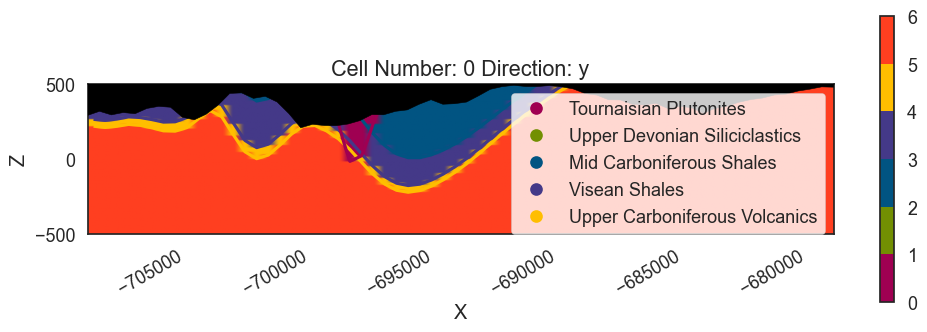

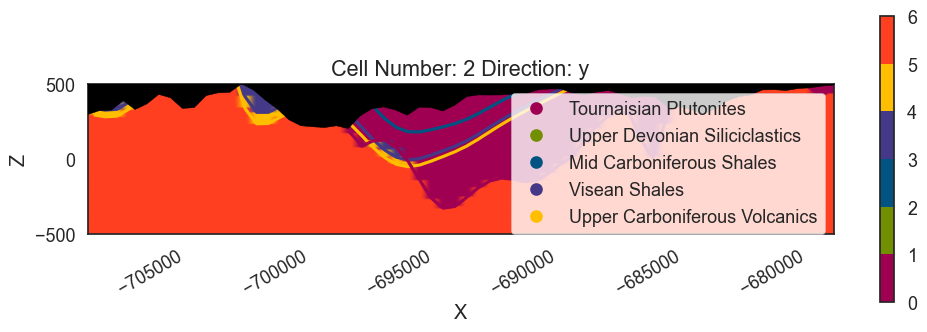

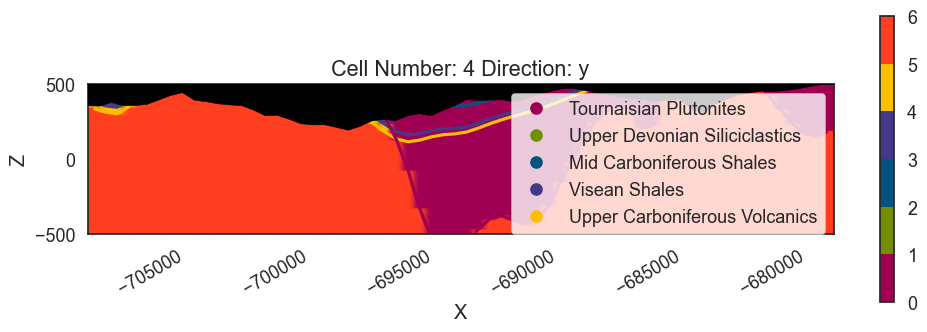

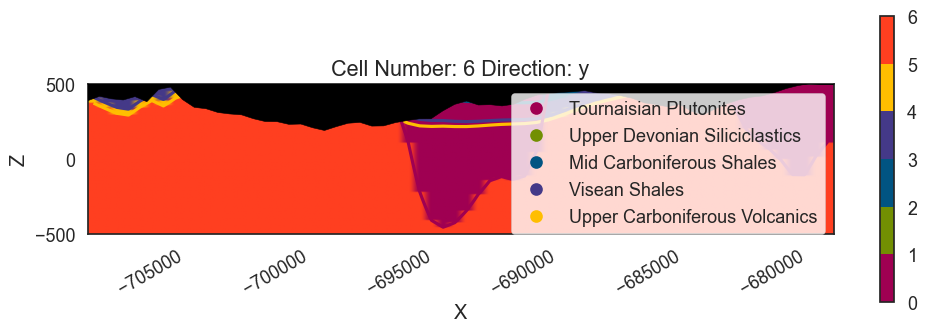

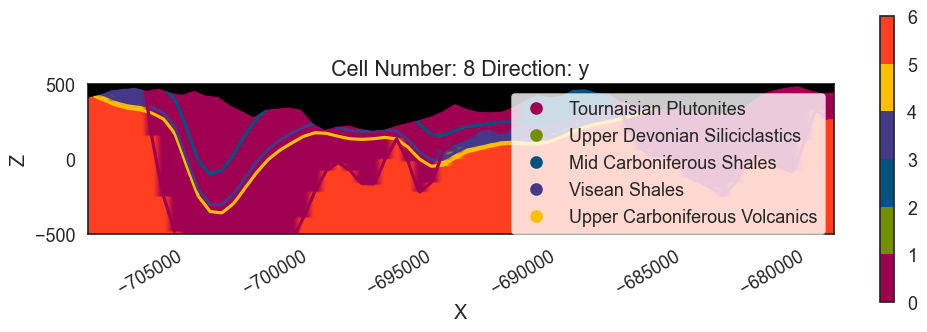

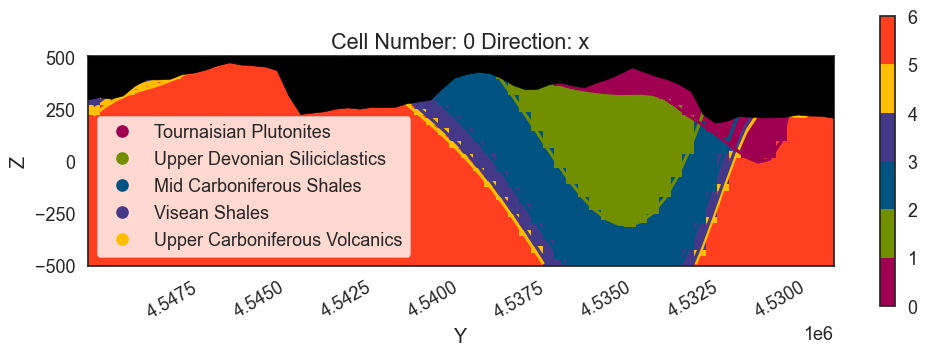

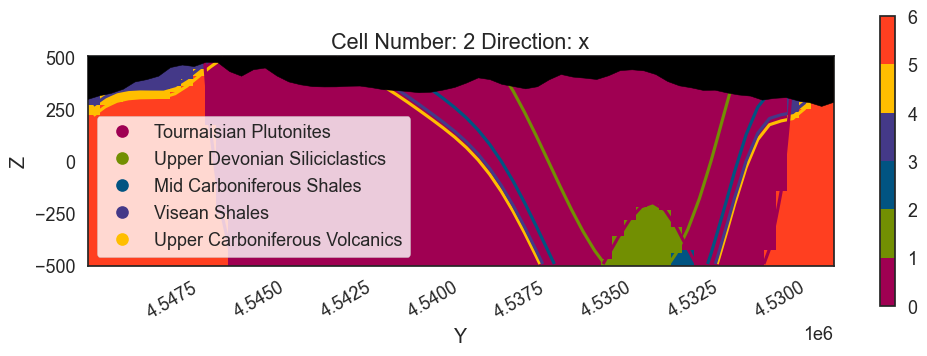

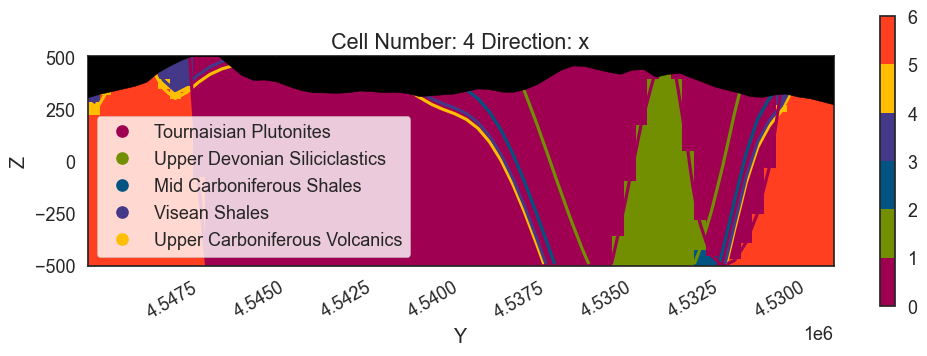

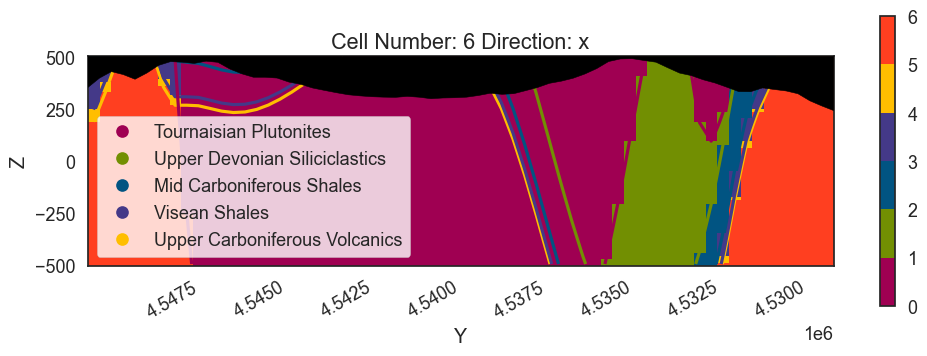

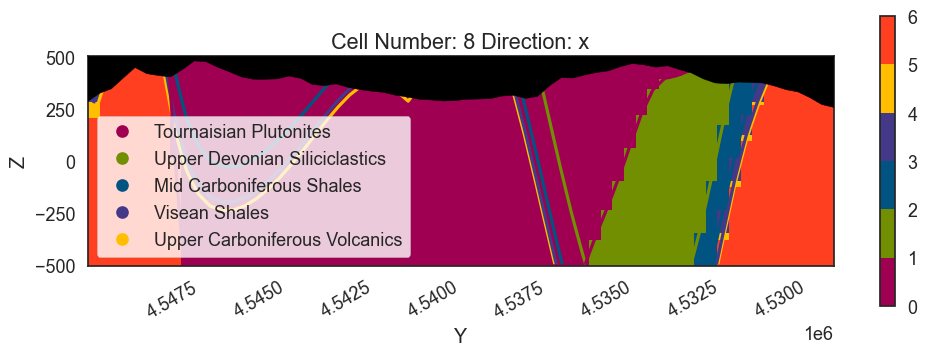

In [16]:
threading.Thread(target=HelperMethods.plot_3d_async, args=(stratigraphic_geo_model,)).start()
trigger_create_cross_section = True
if trigger_create_cross_section:
    print("Creating cross section...")
    HelperMethods.create_cross_section(stratigraphic_geo_model, cross_section=10)
    print("Cross section created!")
else:
    print("Cross section creation is disabled")

stratigraphic_geo_model.structural_frame

# Combining Models

In [17]:
# 1. Get the formation IDs for the model
stratigraphic_lith_block = stratigraphic_geo_model.solutions.raw_arrays.lith_block
stratigraphic_lith_block_reshaped = stratigraphic_lith_block.reshape(64,64,64)

# 2. Get the coordinates of these voxels
voxel_coords = stratigraphic_geo_model.grid.regular_grid.values
voxel_coords_reshaped = voxel_coords.reshape(64, 64, 64, 3)

# 3. Flip Y coordinate
y_min, y_max = np.min(voxel_coords[:, 1]), np.max(voxel_coords[:, 1])
voxel_coords_flipped = voxel_coords.copy()
voxel_coords_flipped[:, 1] = y_max - (voxel_coords[:, 1] - y_min)

# 4. Insert the igneous rock locations into the stratigraphic model by changing the lithology ID at those voxel locations to 6 (Plutonite)
stratigraphic_lith_block_reshaped[plutonite_mask] = 6
stratigraphic_lith_block_modified = stratigraphic_lith_block_reshaped.flatten()


# Find which formations are present in each voxel of the stratigraphic model
# 1 = Upper Carboniferous Volcanics
# 2 = Mid Carboniferous Shales
# 3 = Visean Shales
# 4 = Upper Devonian Siliciclastics

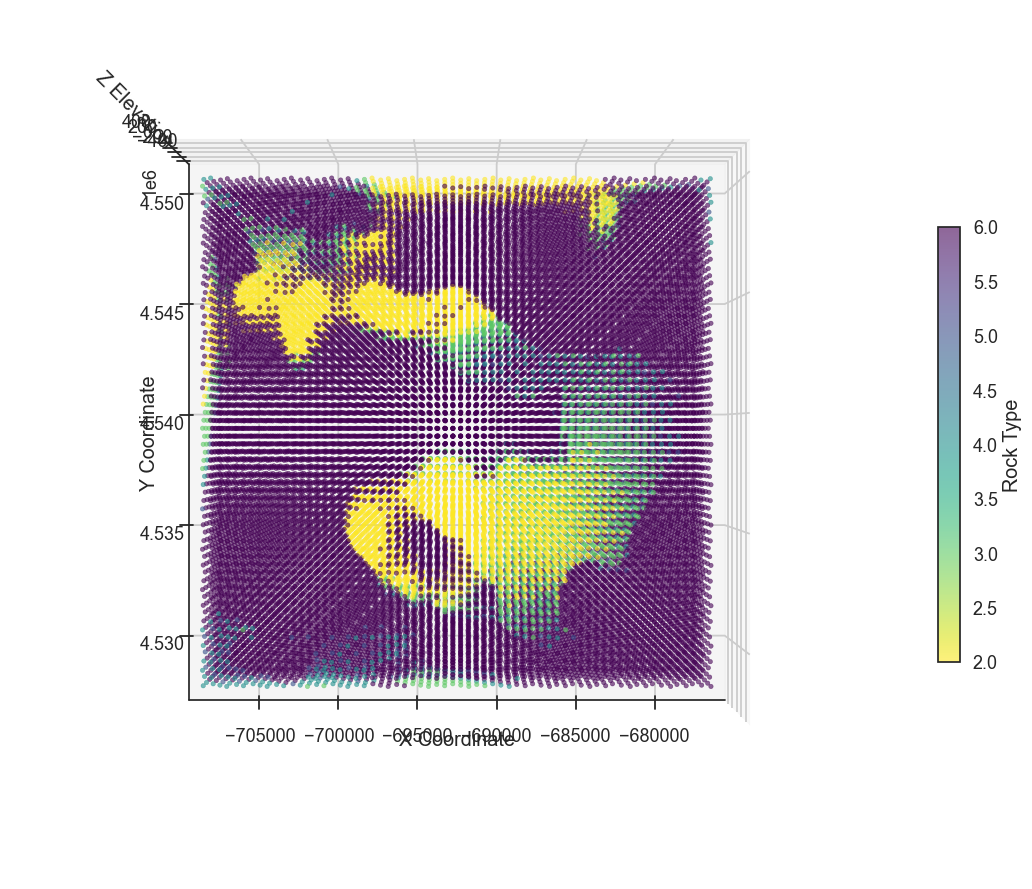

In [18]:
# Sample the plutonite coordinates for better performance
sample_step = 10  # Take every 10th point

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Create the scatter plot with color mapping based on Z values
scatter = ax.scatter(voxel_coords_flipped[:,0][::sample_step], 
                    voxel_coords_flipped[:,1][::sample_step], 
                    voxel_coords_flipped[:,2][::sample_step],
                    c=stratigraphic_lith_block_modified[::sample_step], 
                    cmap='viridis_r', 
                    s=10, 
                    alpha=0.6)

# Add colorbar
plt.colorbar(scatter, ax=ax, label='Rock Type', shrink=0.5)

# Set labels and title
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Z Elevation')

# Improve the view
ax.view_init(elev=90, azim=270)
plt.tight_layout()
plt.show()

# Visual Inspection

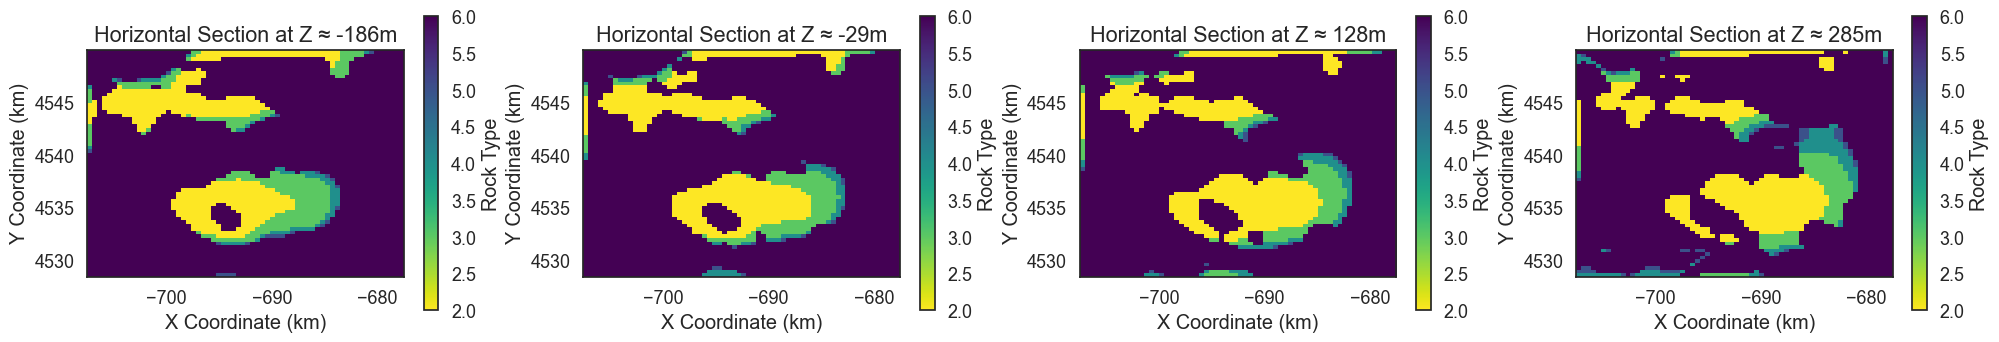

Rock Type Legend:
1: Upper Devonian Siliciclastics
2: Mid Carboniferous Shales
3: Visean Shales
4: Upper Carboniferous Volcanics
5: Basement
6: Tournaisian Plutonites (Intrusion)


In [19]:
# Create multiple cross sections of the combined model
fig, axes = plt.subplots(1, 4, figsize=(20, 15))

# Horizontal cross sections (XY plane) at different Z elevations
z_indices = [20, 30, 40, 50]  # Different Z positions
for i, z_idx in enumerate(z_indices):
    xy_slice = stratigraphic_lith_block_modified.reshape(64, 64, 64)[:, :, z_idx]
    im = axes[i].imshow(xy_slice.T, cmap='viridis_r', origin='lower',
                          extent=[min_x/1000, max_x/1000, min_y/1000, max_y/1000], aspect='equal')
    z_elevation = model_depth + (z_idx / 64) * (max_z - model_depth)
    axes[i].set_title(f'Horizontal Section at Z ≈ {z_elevation:.0f}m')
    axes[i].set_xlabel('X Coordinate (km)')
    axes[i].set_ylabel('Y Coordinate (km)')
    plt.colorbar(im, ax=axes[i], label='Rock Type', shrink=0.2)
plt.tight_layout()
plt.show()

# Add legend for rock types
print("Rock Type Legend:")
print("1: Upper Devonian Siliciclastics")
print("2: Mid Carboniferous Shales") 
print("3: Visean Shales")
print("4: Upper Carboniferous Volcanics")
print("5: Basement")
print("6: Tournaisian Plutonites (Intrusion)")

C:\Users\maxha\PycharmProjects\Mineye-Terranigma\.venv\Lib\site-packages\gempy_viewer\API\_plot_2d_sections_api.py:106: UserWarning: Section contacts not implemented yet. We need to pass scalar field for the sections grid
  warnings.warn(
C:\Users\maxha\PycharmProjects\Mineye-Terranigma\.venv\Lib\site-packages\gempy_viewer\API\_plot_2d_API.py:176: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()


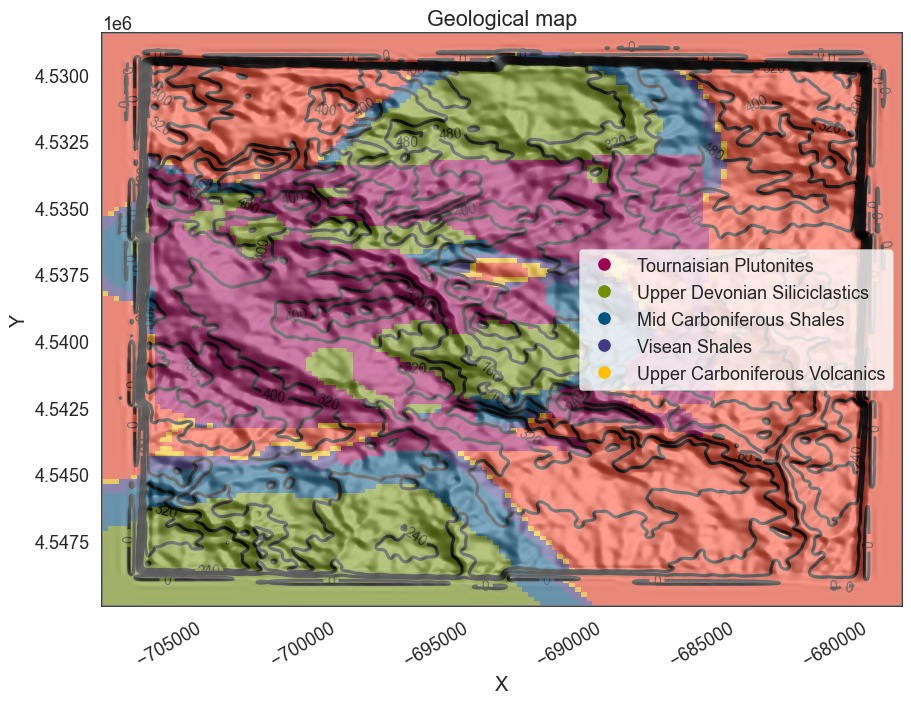

In [30]:
# Plot 2D Map representation

p = gpv.plot_2d(
    stratigraphic_geo_model,
    section_names=['topography'],   # this triggers the top-down geological map
    show_topography=True,
    show_lith=True,
    show_boundaries=True,
    show_data=False,
    kwargs_topography={"hillshade": True, "azdeg": 315, "altdeg": 45},  # optional hillshade
    legend=True,
)



# Exporting Model to Liquid Earth

In [29]:
link = gpv.plot_to_liquid_earth(
    geo_model=stratigraphic_geo_model,
     space_name='Stratigraphic-Plutonic Model',
     file_name="gempy_model_combined",
     user_token='le-4d51ab1b4d814b259b09becf428a2d99UqSmRG2rgjk5f6IrXlWWFprUhX-YPkl0oASdg7VtcME',  # If None, it will try to grab it from the environment
     grab_link=True,
     make_new_space=False )

print(f"Generated Link: {link}")

Generated Link: ServerResponse(deep_link='https://liquidearth.app.link/e5f53f85-ecc5-47ee-b77a-fbbb3a38bddd', available_projects=[AvailableProject(CreationDate='Thursday, 18 September 2025', DisplayedOwner='max@terranigma-solutions.com', Name='Stratigraphic-Plutonic Model', OwnerId='VhHz+3SZcy3I+k7DxNqJKA==:QUCXmYxBZc0V1amgW+Qw5doRmgSgbGyN1er81e0/raF0fLK2r1aURNicM7JIjz8l', SpaceId='D0ZEa2OqdFE9s1K6Neh4OQ==:pdEAkyrHy09O6HQ9qi/Slm5TEtmopkN9gbgXEs6QmcjpWbvtUaXl60nPxyCmi6tV'), AvailableProject(CreationDate='Wednesday, 17 September 2025', DisplayedOwner='max@terranigma-solutions.com', Name='test_aaron_max', OwnerId='BONXL2VY4hRXmJUH5c+Qog==:xH2LtUOCdNq00ms2nA2G2Y4/kKGpRX4QVjw+b9N7rCUR8oGESOtIsZS1Gt7DquNf', SpaceId='ITpQZnFqVHCH45nk8K+FbQ==:22SSbENE9CWaurDT8IVjiBB358tFsbdIPZ86sRcngcxtgeh+GN2gmY2wkN4naBWf'), AvailableProject(CreationDate='Wednesday, 26 March 2025', DisplayedOwner='max@terranigma-solutions.com', Name='meshes', OwnerId='+VMZMhKtOFgQtmGDlpPM7w==:4bE4XgJp0EBtFQF2xwKsP/HGuWx6AcGKi

In [22]:
# # Saving the plutonic model
# with open(os.path.join(geomodel_dir, 'Plutonite-Basement_Models', 'plutonite_geo_model.pkl'), "wb") as f:
#     pickle.dump(plutonite_geo_model, f, protocol=pickle.HIGHEST_PROTOCOL)

In [23]:
# # Saving the plutonic-stratigraphic model
# with open(os.path.join(geomodel_dir, 'Stratigraphic_Models', 'stratigraphic_geo_model.pkl'), "wb") as f:
#     pickle.dump(stratigraphic_geo_model, f, protocol=pickle.HIGHEST_PROTOCOL)

# Plotting without Axis

In [25]:
gpv.plot_3d(stratigraphic_geo_model,
            kwargs_pyvista_bounds={
                "show_xaxis":False,   # no X axis
                "show_yaxis":False,   # no Y axis
                "show_zlabels":False, # no Z labels
                "ztitle":""           # no Z title
            },
            show_lith=True,
            show_topography=True,
            ve=10);